# RC-07 — Cascade, fitted loss and coating-target sensitivity

**2026-09-10 · pre-G1, exploratory, not promoted.**
This recalculation separates corrected SHG normalization from refitting the
loss budget. It preserves the May procurement specification as a comparison.
A fit to one power measurement is calibration, not independent validation.
Inputs and limitations are recorded in the dated RC-07 logbook report.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy
import yaml
from scipy.optimize import brentq

from src.boyd_kleinman import h_m_factor, h_m_optimum
from src.enhancement_cavity import (
    circulating_power,
    harmonic_output_W,
    optimal_input_coupler,
)
from src.shg_cascade import Stage, cascade_output, optimise_cascade
from src.shg_single_pass import gamma_shg_coefficient

SOURCE = Path("notebooks/exploration/2026-09-10-rc07-recalculation.py")
EXTRACTION = Path("data/literature/Friedenauer2006/extracted.yaml")
OUTPUT = Path("data/review/2026-09-10/rc07-results.json")
BASE_REVISION = "4404074d5114ecf7515a2cbd71910c16c036359d"


def fit_passive_loss(
    pump_W: float,
    transmission: float,
    gamma_per_W: float,
    measured_harmonic_W: float,
    extraction_efficiency: float = 1.0,
) -> float:
    """Fit dimensionless fundamental loss to one extracted harmonic power.

    Extraction is downstream of conversion, with no UV feedback. Reject an
    unattainable measurement rather than returning a boundary as a fitted loss.
    """
    if not 0.0 < extraction_efficiency <= 1.0:
        raise ValueError("extraction efficiency must be in (0,1]")
    if not math.isfinite(measured_harmonic_W) or measured_harmonic_W <= 0.0:
        raise ValueError("measured harmonic power must be positive and finite")

    def residual(loss: float) -> float:
        return (
            extraction_efficiency
            * harmonic_output_W(pump_W, transmission, loss, gamma_per_W)
            - measured_harmonic_W
        )

    high = math.nextafter(1.0, 0.0)
    low_residual, high_residual = residual(0.0), residual(high)
    # The forward solver has a 1e-12 relative root tolerance. At a physical
    # endpoint, an equivalent independently generated observation can differ
    # by roundoff. Accept only a correspondingly small *relative output* error.
    output_tolerance = 3e-12 * measured_harmonic_W
    if abs(low_residual) <= output_tolerance:
        return 0.0
    if abs(high_residual) <= output_tolerance:
        return high
    if low_residual < 0.0 or high_residual > 0.0:
        raise ValueError("measured output is outside the passive-loss model range")
    return float(brentq(residual, 0.0, high, xtol=1e-15, rtol=1e-12))


def minimax_coupler(powers_W: list[float], loss: float, gamma: float) -> dict:
    """Equalise relative output penalties for the two endpoint pump scenarios."""
    if len(powers_W) != 2 or not 0.0 < powers_W[0] < powers_W[1]:
        raise ValueError("two positive increasing pump scenarios are required")
    optima = [optimal_input_coupler(p, loss, gamma) for p in powers_W]
    peaks = [
        harmonic_output_W(p, t, loss, gamma)
        for p, t in zip(powers_W, optima, strict=True)
    ]

    def penalty(p: float, t: float, peak: float) -> float:
        return 1.0 - harmonic_output_W(p, t, loss, gamma) / peak

    def difference(t: float) -> float:
        return penalty(powers_W[0], t, peaks[0]) - penalty(powers_W[1], t, peaks[1])

    centre = brentq(difference, *optima, xtol=1e-15)
    return {
        "transmission": float(centre),
        "worst_relative_penalty": max(
            penalty(p, centre, peak) for p, peak in zip(powers_W, peaks, strict=True)
        ),
    }


def material_gamma(
    stage: dict, deff: float, legacy: bool = False
) -> tuple[float, float]:
    """Compute h and γ; legacy reconstructs only the old kernel and prefactor.

    With B_old = B*sqrt(xi), the corrected exponential becomes the old one.
    Multiplying corrected K by n1 restores its missing index factor. Cavity
    solving uses the corrected, regression-tested solver in all comparisons.
    """
    k = 2.0 * math.pi * stage["n1"] / stage["wavelength_m"]
    xi = stage["length_m"] / (k * stage["waist_m"] ** 2)
    beta = stage["rho_rad"] * math.sqrt(stage["length_m"] * k) / 2.0
    h = h_m_factor(xi, beta * math.sqrt(xi) if legacy else beta)
    gamma = gamma_shg_coefficient(
        deff, stage["n1"], stage["n2"], stage["wavelength_m"], stage["length_m"], h
    )
    return h, gamma * stage["n1"] if legacy else gamma


def operating_row(
    power: float, loss: float, gamma: float, waist: float, curved: float
) -> dict:
    """Compute optima and beam-normal peak intensities; powers are in watts."""
    t = optimal_input_coupler(power, loss, gamma)
    pc = circulating_power(power, t, loss, gamma)
    ph = harmonic_output_W(power, t, loss, gamma)
    fixed_t = 0.019965  # historical M1 spec, constants fixed for comparison

    def peak(p: float, w: float) -> float:
        return 2.0 * p / (math.pi * w**2)

    return {
        "pump_W": power,
        "loss": loss,
        "gamma_per_W": gamma,
        "T_opt": t,
        "circulating_W": pc,
        "generated_harmonic_W": ph,
        "I_waist_W_per_m2": peak(pc, waist),
        "I_curved_green_W_per_m2": peak(pc, curved),
        "I_curved_uv_if_same_radius_W_per_m2": peak(ph, curved),
        "I_plane_green_range_W_per_m2": [peak(pc, 200e-6), peak(pc, 150e-6)],
        "historical_M1_generated_W": harmonic_output_W(power, fixed_t, loss, gamma),
        "historical_M1_penalty": 1.0
        - harmonic_output_W(power, fixed_t, loss, gamma) / ph,
        "historical_M1_band_worst_penalty": max(
            1.0 - harmonic_output_W(power, fixed_t + delta, loss, gamma) / ph
            for delta in (-500e-6, 500e-6)
        ),
        "optimum_tolerance_penalties": {
            str(delta): max(
                1.0
                - harmonic_output_W(power, max(0.0, t + sign * delta), loss, gamma) / ph
                for sign in (-1.0, 1.0)
            )
            for delta in (500e-6, 1000e-6, 0.005, 0.010)
        },
    }


def recompute() -> dict:
    """Return reproducible calibration/sensitivity results without binding changes."""
    extracted = yaml.safe_load(EXTRACTION.read_text())
    fp = {v["symbol"]: v["value"] for v in extracted["parameters"] if "value" in v}
    stages = [
        {
            "name": "LBO",
            "pump_W": fp["P_LBO_in"],
            "wavelength_m": fp["lambda_fundamental"],
            "length_m": fp["L_LBO_crystal"],
            "waist_m": fp["w0_LBO_BK_optimum"],
            "T": 1.0 - fp["R_LBO_input_coupler_fundamental"],
            "target_W": fp["P_559_output_stable"],
            "n1": 1.605,
            "n2": 1.620,
            "rho_rad": 0.0,
            "deff_m_per_V": fp["deff_LBO_at_1118"],
        },
        {
            "name": "BBO",
            "pump_W": fp["P_BBO_in"],
            "wavelength_m": fp["lambda_fundamental"] / 2.0,
            "length_m": fp["BBO_crystal_size"][2],
            "waist_m": fp["w0_BBO_BK_optimum"],
            "T": 1.0 - fp["R_BBO_input_coupler_fundamental"],
            "target_W": fp["P_UV_out"],
            "n1": 1.67276,
            "n2": 1.565,
            "rho_rad": 0.0831,
            "deff_m_per_V": 1.44e-12,
        },
    ]
    cases = {}
    for legacy in (True, False):
        label = "legacy_normalization" if legacy else "corrected_normalization"
        gammas = [material_gamma(s, s["deff_m_per_V"], legacy)[1] for s in stages]
        fits = [
            fit_passive_loss(s["pump_W"], s["T"], g, s["target_W"])
            for s, g in zip(stages, gammas, strict=True)
        ]
        per_stage = [
            {
                "name": s["name"],
                "gamma_per_W": g,
                "fixed_T_L_equals_T_W": harmonic_output_W(
                    s["pump_W"], s["T"], s["T"], g
                ),
                "optimized_T_L_equals_T_W": harmonic_output_W(
                    s["pump_W"],
                    optimal_input_coupler(s["pump_W"], s["T"], g),
                    s["T"],
                    g,
                ),
                "fitted_loss": loss,
                "T_opt_with_fitted_loss": optimal_input_coupler(s["pump_W"], loss, g),
            }
            for s, g, loss in zip(stages, gammas, fits, strict=True)
        ]
        cases[label] = {"per_stage": per_stage}
        for loss_label, losses in [
            ("L_equals_T", [s["T"] for s in stages]),
            ("fitted_loss", fits),
        ]:
            fixed = [
                Stage(loss, g, s["T"])
                for s, g, loss in zip(stages, gammas, losses, strict=True)
            ]
            optimum = optimise_cascade(
                stages[0]["pump_W"], list(zip(losses, gammas, strict=True)), [1.0]
            )
            cases[label][loss_label] = {
                "fixed_couplers": cascade_output(stages[0]["pump_W"], fixed, [1.0]),
                "optimized_couplers": cascade_output(
                    stages[0]["pump_W"], optimum, [1.0]
                ),
                "optimized_transmissions": [s.T_IC for s in optimum],
            }

    bbo = stages[1]
    h, gamma = material_gamma(bbo, bbo["deff_m_per_V"])
    fitted_loss = cases["corrected_normalization"]["per_stage"][1]["fitted_loss"]
    k = 2.0 * math.pi * bbo["n1"] / bbo["wavelength_m"]
    xi = bbo["length_m"] / (k * bbo["waist_m"] ** 2)
    B = bbo["rho_rad"] * math.sqrt(bbo["length_m"] * k) / 2.0
    xi_opt, hm_opt = h_m_optimum(B)
    # Spherical Gaussian approximation from the May sweep. Brewster/oblique
    # astigmatism and a separate UV mode are not resolved by this construction.
    q_exit = complex(bbo["length_m"] / 2.0, k * bbo["waist_m"] ** 2 / 2.0)
    q_air = q_exit / bbo["n1"] + (0.0594 - bbo["length_m"]) / 2.0
    curved = math.sqrt(-bbo["wavelength_m"] / (math.pi * (1.0 / q_air).imag))
    histories = {
        "frozen_May": (1.4914e-4, 0.015288),
        "gamma_only_fixed_loss": (gamma, 0.015288),
        "gamma_and_refitted_loss": (gamma, fitted_loss),
    }
    grids = {}
    for label, (g, loss) in histories.items():
        # Preserve the May additive budget for like-for-like comparisons.
        # 3400 ppm is an R-floor envelope, not measured coating transmission.
        nonmirror_proxy = loss - 0.0034
        rows = []
        for mirror_loss in (0.0034, 0.0015, 0.0006, 0.0003):
            total = nonmirror_proxy + mirror_loss
            for power in (0.5, 1.5):
                row = operating_row(power, total, g, bbo["waist_m"], curved)
                row["mirror_loss_sum"] = mirror_loss
                rows.append(row)
        grids[label] = {
            "fitted_or_assumed_loss": loss,
            "nonmirror_proxy": nonmirror_proxy,
            "rows": rows,
            "minimax_default": minimax_coupler([0.5, 1.5], nonmirror_proxy + 0.0015, g),
        }
    sensitivity = []
    for d in (1.30e-12, 1.44e-12, 1.60e-12):
        _, g = material_gamma(bbo, d)
        for extraction in (1.0, 0.95):
            fit = fit_passive_loss(
                bbo["pump_W"], bbo["T"], g, bbo["target_W"], extraction
            )
            total = fit - 0.0034 + 0.0015
            sensitivity.append(
                {
                    "deff_m_per_V": d,
                    "extraction_efficiency": extraction,
                    "gamma_per_W": g,
                    "fitted_loss": fit,
                    "default_minimax": minimax_coupler([0.5, 1.5], total, g),
                    "rows": [
                        operating_row(p, total, g, bbo["waist_m"], curved)
                        for p in (0.5, 1.5)
                    ],
                }
            )
    # Isolate harmonic-index consistency as a sensitivity, not a new accepted
    # Sellmeier extraction. At collinear wave-vector match n2_eff = n1.
    _, gamma_index_matched = material_gamma(
        {**bbo, "n2": bbo["n1"]}, bbo["deff_m_per_V"]
    )
    index_loss = fit_passive_loss(
        bbo["pump_W"], bbo["T"], gamma_index_matched, bbo["target_W"]
    )
    # Loss floors do not determine the measured mirror share. These are
    # sensitivity endpoints, not confidence limits or new hardware budgets.
    mirror_allocation = []
    for assumed_old_mirror_loss in (0.0, 0.0015, 0.0034):
        new_total = fitted_loss - assumed_old_mirror_loss + 0.0015
        mirror_allocation.append(
            {
                "assumed_old_mirror_loss": assumed_old_mirror_loss,
                "new_total_loss": new_total,
                "minimax_default": minimax_coupler([0.5, 1.5], new_total, gamma),
            }
        )
    old_mirror_product_loss = 1.0 - math.prod(1.0 - v for v in (0.0007, 0.0007, 0.002))
    new_mirror_product_loss = 1.0 - math.prod(1.0 - v for v in (0.0003, 0.0003, 0.0009))
    nonmirror_product_loss = (fitted_loss - old_mirror_product_loss) / (
        1.0 - old_mirror_product_loss
    )
    product_total = 1.0 - (1.0 - nonmirror_product_loss) * (
        1.0 - new_mirror_product_loss
    )
    return {
        "base_revision": BASE_REVISION,
        "environment": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "scipy": scipy.__version__,
        },
        "inputs": stages,
        "source_sha256": {
            str(p): hashlib.sha256(p.read_bytes()).hexdigest()
            for p in [
                SOURCE,
                EXTRACTION,
                Path("src/boyd_kleinman.py"),
                Path("src/shg_single_pass.py"),
                Path("src/enhancement_cavity.py"),
                Path("src/shg_cascade.py"),
            ]
        },
        "bbo": {
            "xi": xi,
            "B": B,
            "h_m": h,
            "gamma_per_W": gamma,
            "xi_opt": xi_opt,
            "h_m_opt": hm_opt,
            "waist_opt_m": math.sqrt(bbo["length_m"] / (k * xi_opt)),
            "curved_green_radius_m": curved,
            "frozen_loss_corrected_gamma_output_W": harmonic_output_W(
                bbo["pump_W"], bbo["T"], 0.015288, gamma
            ),
        },
        "cascade": cases,
        "coating_grids": grids,
        "joint_deff_extraction_sensitivity": sensitivity,
        "mirror_allocation_sensitivity": mirror_allocation,
        "multiplicative_loss_sensitivity": {
            "old_mirror_loss": old_mirror_product_loss,
            "new_mirror_loss": new_mirror_product_loss,
            "nonmirror_loss": nonmirror_product_loss,
            "new_total_loss": product_total,
            "minimax_default": minimax_coupler([0.5, 1.5], product_total, gamma),
        },
        "harmonic_index_sensitivity": {
            "n2": bbo["n1"],
            "gamma_per_W": gamma_index_matched,
            "fitted_loss": index_loss,
            "minimax_default": minimax_coupler(
                [0.5, 1.5], index_loss - 0.0034 + 0.0015, gamma_index_matched
            ),
        },
    }

## Results

The main table uses the original material assumptions to isolate the code
correction. The output JSON also varies d_eff, UV extraction and harmonic
index. Generated power is not automatically power delivered through M4'.

BBO: {
  "xi": 1.4131714172673748,
  "B": 18.016560142174747,
  "h_m": 0.03924309675490129,
  "gamma_per_W": 0.00010586566994623877,
  "xi_opt": 1.421116571479191,
  "h_m_opt": 0.03924335351390365,
  "waist_opt_m": 1.9345693395474517e-05,
  "curved_green_radius_m": 0.0002547018213673033,
  "frozen_loss_corrected_gamma_output_W": 0.22887193576694512
}

Cascade: old normalization / corrected normalization
legacy_normalization
{'name': 'LBO', 'gamma_per_W': 0.0003560261361251765, 'fixed_T_L_equals_T_W': 0.6480039546781192, 'optimized_T_L_equals_T_W': 0.7017526398152866, 'fitted_loss': 0.015840593113948385, 'T_opt_with_fitted_loss': 0.03410443755027185}
{'name': 'BBO', 'gamma_per_W': 0.0001491391914228046, 'fixed_T_L_equals_T_W': 0.25991719664950574, 'optimized_T_L_equals_T_W': 0.27093324851645767, 'fitted_loss': 0.015287567992627609, 'T_opt_with_fitted_loss': 0.021691503087156082}
L_equals_T fixed UV W: 0.14332746682660594 optimized UV W: 0.16743526473971074
fitted_loss fixed UV W: 0.2750

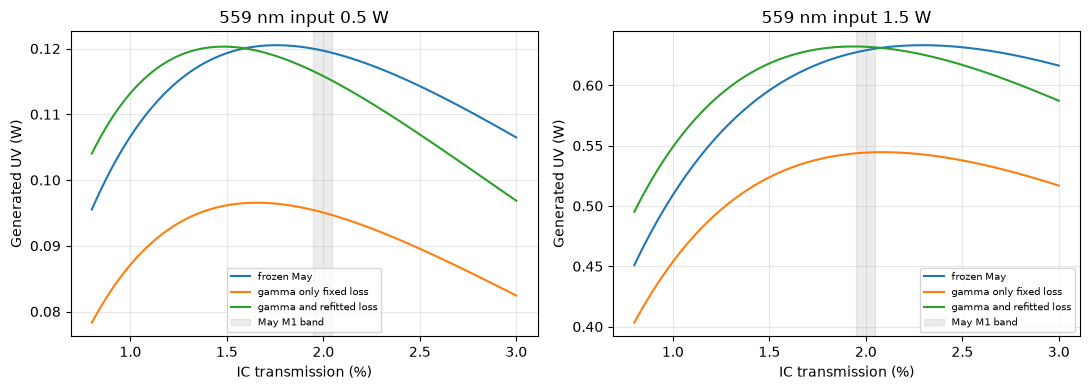

In [2]:
if __name__ == "__main__":
    results = recompute()
    OUTPUT.parent.mkdir(parents=True, exist_ok=True)
    OUTPUT.write_text(json.dumps(results, indent=2, allow_nan=False) + "\n")
    print("BBO:", json.dumps(results["bbo"], indent=2))
    print("\nCascade: old normalization / corrected normalization")
    for label, result in results["cascade"].items():
        print(label)
        for stage in result["per_stage"]:
            print(stage)
        for scenario in ("L_equals_T", "fitted_loss"):
            print(
                scenario,
                "fixed UV W:",
                result[scenario]["fixed_couplers"]["total_harmonic_W"],
                "optimized UV W:",
                result[scenario]["optimized_couplers"]["total_harmonic_W"],
            )
    print("\nCoating comparison: default 1500 ppm mirror budget")
    for label, group in results["coating_grids"].items():
        print(label, "minimax:", group["minimax_default"])
        for row in group["rows"]:
            if row["mirror_loss_sum"] == 0.0015:
                print(
                    f"  P={row['pump_W']:.2f} W: Topt={row['T_opt']*100:.4f} %, "
                    f"Pc={row['circulating_W']:.3f} W, "
                    f"generated UV={row['generated_harmonic_W']:.5f} W, "
                    "May M1 worst-band penalty="
                    f"{row['historical_M1_band_worst_penalty']*100:.3f} %"
                )
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    transmissions = np.linspace(0.008, 0.030, 180)
    for axis, pump in zip(axes, (0.5, 1.5), strict=True):
        for label, group in results["coating_grids"].items():
            row = next(
                r
                for r in group["rows"]
                if r["mirror_loss_sum"] == 0.0015 and r["pump_W"] == pump
            )
            values = [
                harmonic_output_W(pump, t, row["loss"], row["gamma_per_W"])
                for t in transmissions
            ]
            axis.plot(100 * transmissions, values, label=label.replace("_", " "))
        axis.axvspan(1.9465, 2.0465, color="grey", alpha=0.15, label="May M1 band")
        axis.set(
            title=f"559 nm input {pump} W",
            xlabel="IC transmission (%)",
            ylabel="Generated UV (W)",
        )
        axis.grid(alpha=0.3)
        axis.legend(fontsize=7)
    fig.tight_layout()